# Phase 2 — Huấn luyện và Đánh giá Mô hình theo Thiết kế Leave-One-Group-Out

**Mục đích:** Đánh giá khả năng tổng quát hóa của ba mô hình phân loại (KNN, Random Forest, XGBoost) trên bộ dữ liệu CIC-DDoS 2019, sử dụng 18 đặc trưng FAMS được chọn ở Phase 1.

**Thiết kế thực nghiệm:** Leave-One-Group-Out (LOGO) — mỗi thí nghiệm huấn luyện trên một nhóm tấn công và đánh giá trên các nhóm còn lại chưa thấy trong huấn luyện.

| Thí nghiệm | Train | Test (chưa thấy) |
|---|---|---|
| Exp 1 | G1 — Reflection/Application + Benign | G2 + G3 + Benign |
| Exp 2 | G2 — Reflection/Volume + Benign | G1 + G3 + Benign |
| Exp 3 | G3 — Exploitation + Benign | G1 + G2 + Benign |

**Phân nhóm tấn công (CIC-DDoS 2019):**
- **G1 — Reflection/Application:** MSSQL, DNS, LDAP, NetBIOS, SNMP, Portmap
- **G2 — Reflection/Volume:** NTP, TFTP
- **G3 — Exploitation:** Syn, UDP, UDPLag, WebDDoS

**Thiết kế kỹ thuật:**
- Tiền xử lý: RobustScaler (bền với outlier trong network traffic)
- Tối ưu siêu tham số: Optuna TPE, 30 trial, objective = F2-score (β=2)
- Đánh giá nội bộ: 5-fold Stratified CV, subsample 100.000 mẫu, scoring F2
- Cân bằng lớp: `class_weight='balanced'` (RF), `scale_pos_weight` tương ứng (XGB); KNN không hỗ trợ
- KNN: `algorithm='ball_tree'` cố định để đảm bảo so sánh nhất quán về thời gian suy luận
- Benign split 70/30 một lần duy nhất, dùng chung ba thí nghiệm để tránh rò rỉ dữ liệu

In [ ]:
import os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import RobustScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, fbeta_score, roc_auc_score,
    roc_curve, confusion_matrix, make_scorer,
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('Imports OK.')

In [ ]:
SEED = 42
np.random.seed(SEED)

# ── Đường dẫn ─────────────────────────────────────────────────────────────────
CIC_DDOS2019_DIR   = 'data/ddos2019/'
FAMS_FEATURES_FILE = 'fams_features.json'   # output từ Phase 1

# ── Siêu tham số thực nghiệm ──────────────────────────────────────────────────
OPTUNA_TRIALS    = 30
OPTUNA_SUBSAMPLE = 50_000    # số mẫu tối đa cho mỗi Optuna trial
CV_FOLDS         = 5
CV_CAP           = 100_000   # số mẫu tối đa cho cross-validation

# ── Chuẩn hoá nhãn CIC-DDoS 2019 ─────────────────────────────────────────────
def normalise_label(lbl: str) -> str:
    lbl = str(lbl).strip()
    mapping = {
        'DrDoS_DNS':    'DNS',    'DrDoS_LDAP':    'LDAP',
        'DrDoS_MSSQL':  'MSSQL',  'DrDoS_NetBIOS': 'NetBIOS',
        'DrDoS_NTP':    'NTP',    'DrDoS_SNMP':    'SNMP',
        'DrDoS_SSDP':   'SSDP',   'DrDoS_UDP':     'UDP',
        'UDP-lag':      'UDPLag',
    }
    return mapping.get(lbl, lbl)

# ── Phân nhóm tấn công theo taxonomy CIC-DDoS 2019 ───────────────────────────
ATTACK_GROUPS = {
    'G1_Reflection_Application': ['MSSQL', 'DNS', 'LDAP', 'NetBIOS', 'SNMP', 'Portmap'],
    'G2_Reflection_Volume':      ['NTP', 'TFTP'],
    'G3_Exploitation':           ['Syn', 'UDP', 'UDPLag', 'WebDDoS'],
}
LABEL_TO_GROUP = {lbl: grp for grp, lbls in ATTACK_GROUPS.items() for lbl in lbls}

# ── Màu sắc biểu đồ ───────────────────────────────────────────────────────────
COLORS = {'KNN': 'steelblue', 'RF': 'darkorange', 'XGB': 'forestgreen'}

# ── Nạp FAMS features từ Phase 1 ─────────────────────────────────────────────
with open(FAMS_FEATURES_FILE) as fp:
    FAMS_FEATURES = json.load(fp)
print(f'FAMS features ({len(FAMS_FEATURES)}): {FAMS_FEATURES}')

## 1. Nạp và Chuẩn hoá Dữ liệu

Nạp tất cả file Parquet từ thư mục CIC-DDoS 2019, chuẩn hoá nhãn về dạng thống nhất (ví dụ: `DrDoS_DNS` → `DNS`), và chỉ giữ lại 18 đặc trưng FAMS từ Phase 1 để giảm bộ nhớ và đảm bảo nhất quán với giai đoạn chọn đặc trưng.

In [3]:
pq_files = sorted([
    os.path.join(CIC_DDOS2019_DIR, f)
    for f in os.listdir(CIC_DDOS2019_DIR) if f.endswith('.parquet')
])
print(f'Tìm thấy {len(pq_files)} file Parquet')

frames = []
for fpath in pq_files:
    df_tmp = pd.read_parquet(fpath)
    df_tmp.columns = df_tmp.columns.str.strip()
    df_tmp['Label'] = df_tmp['Label'].astype(str).str.strip().map(normalise_label)

    # Chỉ giữ FAMS features + Label
    keep = [c for c in FAMS_FEATURES if c in df_tmp.columns] + ['Label']
    frames.append(df_tmp[keep])

df_raw = pd.concat(frames, ignore_index=True)
print(f'\nDDoS 2019 đã nạp: {len(df_raw):,} dòng')
print('Phân phối nhãn (sau chuẩn hoá):')
print(df_raw['Label'].value_counts())

# Kiểm tra FAMS features có đủ không
missing = [f for f in FAMS_FEATURES if f not in df_raw.columns]
if missing:
    print(f'\n[WARNING] Đặc trưng vắng mặt trong DDoS 2019: {missing}')
else:
    print(f'\nTất cả {len(FAMS_FEATURES)} FAMS features có trong DDoS 2019. OK.')

Tìm thấy 17 file Parquet



DDoS 2019 đã nạp: 431,371 dòng
Phân phối nhãn (sau chuẩn hoá):
Label
NTP        121368
TFTP        98917
Benign      97831
Syn         49373
UDP         28510
MSSQL       14735
UDPLag       8927
DNS          3669
LDAP         3346
SNMP         2717
NetBIOS      1242
Portmap       685
WebDDoS        51
Name: count, dtype: int64

Tất cả 18 FAMS features có trong DDoS 2019. OK.


## 2. Tiền xử lý và Mã hoá Nhãn

Ép kiểu số cho tất cả đặc trưng, thay thế giá trị vô cực (±∞) bằng NaN, loại bỏ hàng thiếu và trùng lặp. Tạo nhãn nhị phân (`label_bin`: 0 = Benign, 1 = Attack) và gán mỗi mẫu tấn công vào nhóm tương ứng theo taxonomy CIC-DDoS 2019.

In [4]:
feat_cols = [f for f in FAMS_FEATURES if f in df_raw.columns]
df = df_raw.copy()

# Ép kiểu, ±∞ → NaN, dropna, dedup
for col in feat_cols:
    if df[col].dtype == object:
        df[col] = pd.to_numeric(df[col], errors='coerce')
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)
df.drop_duplicates(inplace=True)
print(f'Sau tiền xử lý: {len(df):,} dòng')

# Mã hoá nhãn nhị phân
df['label_bin'] = (df['Label'].str.upper() != 'BENIGN').astype(int)

# Phân nhóm
df['Group'] = df['Label'].map(LABEL_TO_GROUP)

print('\nSố dòng theo nhóm:')
grp_counts = df.groupby('Group')['label_bin'].agg(['count', 'sum'])
grp_counts.columns = ['Tổng', 'Tấn công']
grp_counts['Benign'] = grp_counts['Tổng'] - grp_counts['Tấn công']
print(grp_counts.to_string())

print('\nSố dòng theo loại tấn công trong từng nhóm:')
for grp in ATTACK_GROUPS:
    sub = df[df['Group'] == grp]['Label'].value_counts()
    print(f'\n  {grp}:')
    print(sub.to_string())

Sau tiền xử lý: 388,505 dòng



Số dòng theo nhóm:
                             Tổng  Tấn công  Benign
Group                                              
G1_Reflection_Application   22839     22839       0
G2_Reflection_Volume       200705    200705       0
G3_Exploitation             77471     77471       0

Số dòng theo loại tấn công trong từng nhóm:

  G1_Reflection_Application:
Label
MSSQL      12227
DNS         3669
LDAP        2722
SNMP        2715
NetBIOS      833
Portmap      673

  G2_Reflection_Volume:
Label
NTP     113333
TFTP     87372



  G3_Exploitation:
Label
Syn        42746
UDP        26227
UDPLag      8447
WebDDoS       51


## 3. Phân chia Dữ liệu Benign

Tách riêng lưu lượng Benign và lưu lượng tấn công. Benign được chia ngẫu nhiên 70/30 (train/test) **một lần duy nhất**, dùng chung cho cả ba thí nghiệm LOGO. Cách này đảm bảo không có Benign trùng lặp giữa tập train và test, đồng thời loại bỏ nguy cơ rò rỉ dữ liệu giữa các thí nghiệm.

In [5]:
benign_df = df[df['label_bin'] == 0].copy()
attack_df = df[df['label_bin'] == 1].copy()

# Random 70/30 — không cần stratify (chỉ 1 nhãn)
ben_train, ben_test = train_test_split(
    benign_df, test_size=0.30, random_state=SEED
)
print(f'Benign  : {len(benign_df):,} dòng')
print(f'ben_train: {len(ben_train):,} (70%)')
print(f'ben_test : {len(ben_test):,}  (30%)')

print('\nTấn công theo nhóm:')
for grp, attacks in ATTACK_GROUPS.items():
    n = len(attack_df[attack_df['Group'] == grp])
    low = [a for a in attacks if len(attack_df[attack_df['Label']==a]) < 200]
    warn = f'  ⚠ rất ít: {low}' if low else ''
    print(f'  {grp}: {n:,} dòng{warn}')

Benign  : 87,490 dòng
ben_train: 61,243 (70%)
ben_test : 26,247  (30%)

Tấn công theo nhóm:
  G1_Reflection_Application: 22,839 dòng


  G2_Reflection_Volume: 200,705 dòng
  G3_Exploitation: 77,471 dòng  ⚠ rất ít: ['WebDDoS']


## 4. Thiết kế Thực nghiệm — Model Registry và Experiment Engine

Mỗi thí nghiệm LOGO được thực hiện theo quy trình chuẩn:

1. **Xây dựng tập train/test** — `ben_train` + nhóm tấn công huấn luyện; `ben_test` + các nhóm chưa thấy
2. **Chuẩn hoá** — RobustScaler fit trên tập train, transform cả train và test
3. **Tối ưu siêu tham số** — Optuna TPE, 30 trial, subsample 50.000 mẫu, mục tiêu F2 (β=2)
4. **Cross-validation** — 5-fold StratifiedKFold, scoring F2, capped 100.000 mẫu
5. **Huấn luyện cuối** — fit trên toàn bộ tập train với siêu tham số tốt nhất
6. **Đánh giá** — trên tập test (nhóm tấn công chưa thấy): Accuracy, Precision, Recall, F1, F2, FNR, AUC, Gap

**Gap = CV F2 − Test F2**: chỉ số định lượng mức độ overfit vào nhóm tấn công huấn luyện. Gap > 0,10 được xem là cảnh báo tổng quát hóa kém.

In [ ]:
def build_model_registry(neg_count: int, pos_count: int) -> dict:
    """Trả về registry các mô hình với không gian tìm kiếm siêu tham số Optuna.

    Args:
        neg_count: số mẫu Benign trong tập train
        pos_count: số mẫu tấn công trong tập train
    Returns:
        dict mname → {note, param_space, build}
    """
    scale_pos_weight = neg_count / max(pos_count, 1)
    return {
        'KNN': {
            'note': 'algorithm=ball_tree cố định; không hỗ trợ class_weight',
            'param_space': lambda trial: {
                'n_neighbors': trial.suggest_int('n_neighbors', 1, 30),
                'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
            },
            'build': lambda p: KNeighborsClassifier(**p, algorithm='ball_tree', n_jobs=-1),
        },
        'RF': {
            'note': 'class_weight=balanced',
            'param_space': lambda trial: {
                'n_estimators':      trial.suggest_int('n_estimators', 50, 300),
                'max_depth':         trial.suggest_int('max_depth', 5, 30),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
                'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2']),
            },
            'build': lambda p: RandomForestClassifier(
                **p, class_weight='balanced', n_jobs=-1, random_state=SEED),
        },
        'XGB': {
            'note': f'scale_pos_weight={scale_pos_weight:.2f}',
            'param_space': lambda trial: {
                'n_estimators':     trial.suggest_int('n_estimators', 50, 300),
                'max_depth':        trial.suggest_int('max_depth', 3, 12),
                'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
                'subsample':        trial.suggest_float('subsample', 0.5, 1.0),
                'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
                'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
            },
            'build': lambda p: XGBClassifier(
                **p, scale_pos_weight=scale_pos_weight,
                eval_metric='logloss', random_state=SEED, n_jobs=-1, verbosity=0),
        },
    }


print('Model registry OK.')

In [ ]:
def run_experiment(exp_name: str, train_group: str, test_groups: list) -> dict | None:
    """Chạy một thí nghiệm Leave-One-Group-Out.

    Args:
        exp_name:    tên thí nghiệm (dùng cho log)
        train_group: tên nhóm tấn công dùng để huấn luyện
        test_groups: danh sách nhóm tấn công dùng để kiểm tra
    Returns:
        dict chứa kết quả, hoặc None nếu không đủ dữ liệu
    """
    print(f'\n{"="*65}')
    print(f'  {exp_name}')
    print(f'  Train: Benign (70%) + {train_group}')
    print(f'  Test : Benign (30%) + {test_groups}')
    print(f'{"="*65}')

    tr_atk = attack_df[attack_df['Group'] == train_group]
    te_atk = attack_df[attack_df['Group'].isin(test_groups)]

    if len(tr_atk) < 10:
        print(f'[SKIP] Không đủ mẫu tấn công: {len(tr_atk)}')
        return None

    train_df = pd.concat([ben_train, tr_atk], ignore_index=True)
    test_df  = pd.concat([ben_test,  te_atk], ignore_index=True)

    X_tr = train_df[feat_cols].values.astype(np.float32)
    y_tr = train_df['label_bin'].values
    X_te = test_df[feat_cols].values.astype(np.float32)
    y_te = test_df['label_bin'].values

    cnt_tr = Counter(y_tr)
    print(f'  Train: {len(X_tr):,} | Benign={cnt_tr[0]:,} | Attack={cnt_tr[1]:,} | ratio={cnt_tr[0]/max(cnt_tr[1],1):.1f}:1')
    print(f'  Test : {len(X_te):,} | Benign={Counter(y_te)[0]:,} | Attack={Counter(y_te)[1]:,}')

    # Chuẩn hoá — fit trên train, transform cả hai
    sc = RobustScaler()
    X_tr_sc = sc.fit_transform(X_tr)
    X_te_sc = sc.transform(X_te)

    registry = build_model_registry(cnt_tr[0], cnt_tr[1])

    # Subsample cho Optuna (tránh quá lâu với tập lớn)
    n_sub = min(len(X_tr_sc), OPTUNA_SUBSAMPLE)
    idx_sub = np.random.RandomState(SEED).choice(len(X_tr_sc), n_sub, replace=False)
    X_sub, y_sub = X_tr_sc[idx_sub], y_tr[idx_sub]
    X_opt_tr, X_opt_val, y_opt_tr, y_opt_val = train_test_split(
        X_sub, y_sub, test_size=0.20, random_state=SEED, stratify=y_sub
    )

    # Subsample cho CV (tránh quá lâu với tập lớn)
    n_cv = min(len(X_tr_sc), CV_CAP)
    idx_cv = np.random.RandomState(SEED).choice(len(X_tr_sc), n_cv, replace=False)
    X_cv, y_cv = X_tr_sc[idx_cv], y_tr[idx_cv]
    cv_splitter = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
    f2_scorer   = make_scorer(fbeta_score, beta=2, zero_division=0)

    exp_results = {}
    for mname, cfg in registry.items():
        print(f'\n  [{mname}] {cfg["note"]}')

        # Tối ưu siêu tham số bằng Optuna TPE
        print(f'  Optuna {OPTUNA_TRIALS} trials ... ', end='', flush=True)
        t0 = time.time()

        def make_objective(cfg_inner, Xtr, ytr, Xval, yval):
            def objective(trial):
                m = cfg_inner['build'](cfg_inner['param_space'](trial))
                m.fit(Xtr, ytr)
                return fbeta_score(yval, m.predict(Xval), beta=2, zero_division=0)
            return objective

        study = optuna.create_study(
            direction='maximize',
            sampler=optuna.samplers.TPESampler(seed=SEED),
        )
        study.optimize(
            make_objective(cfg, X_opt_tr, y_opt_tr, X_opt_val, y_opt_val),
            n_trials=OPTUNA_TRIALS, show_progress_bar=False,
        )
        print(f'best_F2_val={study.best_value:.4f}  ({time.time()-t0:.1f}s)')

        # 5-fold CV với siêu tham số tốt nhất
        cv_model  = cfg['build'](study.best_params)
        cv_scores = cross_val_score(cv_model, X_cv, y_cv, cv=cv_splitter, scoring=f2_scorer, n_jobs=-1)
        print(f'  5-fold CV F2: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

        # Huấn luyện cuối trên toàn bộ tập train
        final = cfg['build'](study.best_params)
        t0 = time.time()
        final.fit(X_tr_sc, y_tr)
        train_time_s = time.time() - t0

        # Dự đoán trên tập test
        y_pred  = final.predict(X_te_sc)
        y_proba = final.predict_proba(X_te_sc)[:, 1]

        # Đo thời gian suy luận (5 lần lặp, 5000 mẫu)
        N_INFER, REPEATS = min(5_000, len(X_te_sc)), 5
        X_infer = X_te_sc[:N_INFER]
        t0 = time.time()
        for _ in range(REPEATS):
            final.predict(X_infer)
        infer_ms = (time.time() - t0) / REPEATS / N_INFER * 1_000

        print(f'  Thời gian: train={train_time_s:.2f}s | infer={infer_ms:.4f}ms/mẫu')

        # Tính các chỉ số phân loại
        tn, fp, fn, tp = confusion_matrix(y_te, y_pred).ravel()
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0

        result = {
            'CV_F2_mean':          round(float(cv_scores.mean()), 4),
            'CV_F2_std':           round(float(cv_scores.std()),  4),
            '_cv_scores':          cv_scores,
            'Accuracy':            round(accuracy_score(y_te, y_pred), 4),
            'Precision':           round(precision_score(y_te, y_pred, zero_division=0), 4),
            'Recall':              round(recall_score(y_te, y_pred, zero_division=0), 4),
            'F1':                  round(f1_score(y_te, y_pred, zero_division=0), 4),
            'F2':                  round(fbeta_score(y_te, y_pred, beta=2, zero_division=0), 4),
            'FNR':                 round(fnr, 4),
            'AUC':                 round(roc_auc_score(y_te, y_proba), 4),
            'Train_Time_s':        round(train_time_s, 2),
            'Infer_ms_per_sample': round(infer_ms, 4),
            'Best_Params':         study.best_params,
            '_study':              study,
            '_model':              final,
            '_scaler':             sc,
            '_y_pred':             y_pred,
            '_y_proba':            y_proba,
        }
        gap  = result['CV_F2_mean'] - result['F2']
        flag = '  [!] gap lớn' if abs(gap) > 0.10 else ''
        print(f'  Test: F2={result["F2"]:.4f} | Recall={result["Recall"]:.4f} | '
              f'FNR={result["FNR"]:.4f} | AUC={result["AUC"]:.4f} | Gap={gap:+.4f}{flag}')
        exp_results[mname] = result

    return {
        'results':      exp_results,
        'y_test':       y_te,
        'X_test_sc':    X_te_sc,
        'train_group':  train_group,
        'test_groups':  test_groups,
    }


print('Experiment engine OK.')

## 5. Chạy Ba Thí nghiệm Leave-One-Group-Out

In [7]:
EXPERIMENTS = {
    'Exp1: Train G1 → Test G2+G3': (
        'G1_Reflection_Application',
        ['G2_Reflection_Volume', 'G3_Exploitation']
    ),
    'Exp2: Train G2 → Test G1+G3': (
        'G2_Reflection_Volume',
        ['G1_Reflection_Application', 'G3_Exploitation']
    ),
    'Exp3: Train G3 → Test G1+G2 ⚠': (
        'G3_Exploitation',
        ['G1_Reflection_Application', 'G2_Reflection_Volume']
    ),
}

all_experiments = {}
for exp_name, (train_grp, test_grps) in EXPERIMENTS.items():
    result = run_experiment(exp_name, train_grp, test_grps)
    if result:
        all_experiments[exp_name] = result

print(f'\nHoàn thành {len(all_experiments)}/3 thí nghiệm.')


  Exp1: Train G1 → Test G2+G3
  Train: ben_train + G1_Reflection_Application
  Test : ben_test  + ['G2_Reflection_Volume', 'G3_Exploitation']
  Train: 84,082 | Benign=61,243 Attack=22,839 | ratio=2.7:1


  Test : 304,423 | Benign=26,247 Attack=278,176



  [KNN] Không hỗ trợ class_weight — chạy không cân bằng lớp
  Optuna 30 trials ... 

best_F2_val=0.9944 (54.3s)


  5-fold CV F2: 0.9952 ± 0.0008


...

  Train time: 4.94s | Infer time: 0.0106 ms/sample


  Test → F2=0.9848 | Recall=0.9811 | FNR=0.0189 | AUC=0.9990 | Gap=+0.0133

  [XGB] scale_pos_weight=0.79
  Optuna 30 trials ... 

best_F2_val=0.9972 (81.4s)


  5-fold CV F2: 0.9978 ± 0.0002


  Train time: 4.28s | Infer time: 0.0011 ms/sample
  Test → F2=0.9022 | Recall=0.8807 | FNR=0.1193 | AUC=0.9981 | Gap=+0.0956

Hoàn thành 3/3 thí nghiệm.


## 6. Kết quả Thực nghiệm

### 6.1 Bảng tổng hợp và Heatmap Test F2

                   Thí nghiệm Model         CV_F2  Test_F2  Test_F1  Recall    FNR    AUC    Gap
  Exp1: Train G1 → Test G2+G3   KNN 0.9952±0.0008   0.6027   0.7081  0.5482 0.4518 0.7733 0.3925
  Exp1: Train G1 → Test G2+G3    RF 0.9972±0.0006   0.8332   0.8888  0.7999 0.2001 0.9844 0.1640
  Exp1: Train G1 → Test G2+G3   XGB 0.9976±0.0005   0.7764   0.8474  0.7353 0.2647 0.9887 0.2212
  Exp2: Train G2 → Test G1+G3   KNN 0.9991±0.0001   0.6215   0.7241  0.5679 0.4321 0.7863 0.3776
  Exp2: Train G2 → Test G1+G3    RF 0.9995±0.0001   0.6196   0.7226  0.5658 0.4342 0.8047 0.3799
  Exp2: Train G2 → Test G1+G3   XGB 0.9993±0.0002   0.6221   0.7247  0.5684 0.4316 0.8989 0.3772
Exp3: Train G3 → Test G1+G2 ⚠   KNN 0.9937±0.0007   0.9171   0.9462  0.8987 0.1013 0.9453 0.0766
Exp3: Train G3 → Test G1+G2 ⚠    RF 0.9981±0.0004   0.9848   0.9904  0.9811 0.0189 0.9990 0.0133
Exp3: Train G3 → Test G1+G2 ⚠   XGB 0.9978±0.0002   0.9022   0.9364  0.8807 0.1193 0.9981 0.0956


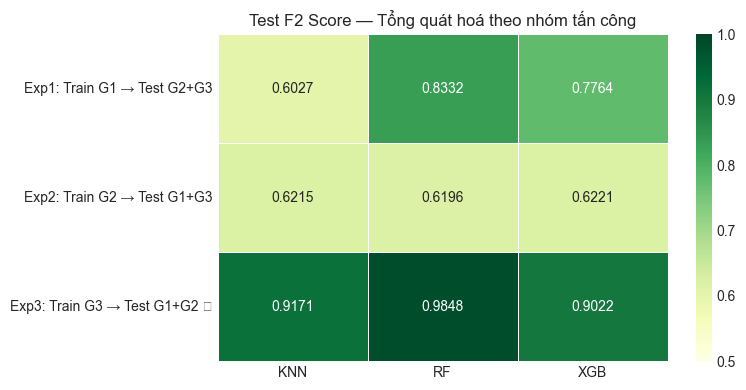

In [8]:
# ── Bảng tổng hợp ─────────────────────────────────────────────────────────────
rows = []
for exp_name, exp in all_experiments.items():
    for mname, r in exp['results'].items():
        gap = r['CV_F2_mean'] - r['F2']
        rows.append({
            'Thí nghiệm': exp_name[:30],
            'Model':      mname,
            'CV_F2':      f"{r['CV_F2_mean']:.4f}±{r['CV_F2_std']:.4f}",
            'Test_F2':    r['F2'],
            'Test_F1':    r['F1'],
            'Recall':     r['Recall'],
            'FNR':        r['FNR'],
            'AUC':        r['AUC'],
            'Gap':        round(gap, 4),
        })

summary_df = pd.DataFrame(rows)
print(summary_df.to_string(index=False))

# Heatmap F2
pivot = summary_df.pivot(index='Thí nghiệm', columns='Model', values='Test_F2')
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(pivot.astype(float), annot=True, fmt='.4f', cmap='YlGn',
            vmin=0.5, vmax=1.0, ax=ax, linewidths=0.5)
ax.set_title('Test F2 Score — Tổng quát hoá theo nhóm tấn công')
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_heatmap.png", dpi=150, bbox_inches='tight')
plt.show()

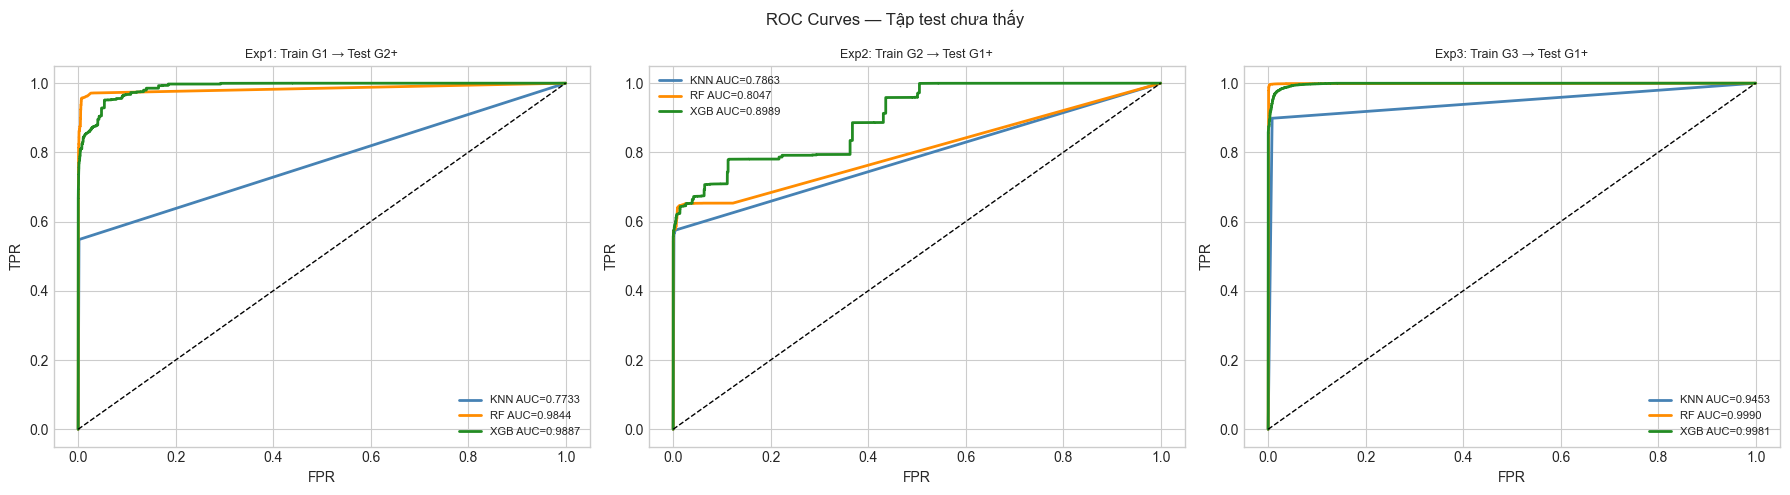

In [9]:
# ── Đường cong ROC ────────────────────────────────────────────────────────────
n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(6*n_exp, 5))
if n_exp == 1: axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    y_te = exp['y_test']
    for mname, r in exp['results'].items():
        fpr, tpr, _ = roc_curve(y_te, r['_y_proba'])
        ax.plot(fpr, tpr, color=COLORS[mname], lw=2,
                label=f"{mname} AUC={r['AUC']:.4f}")
    ax.plot([0,1],[0,1],'k--',lw=1)
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.set_title(exp_name[:25], fontsize=9)
    ax.legend(fontsize=8)

plt.suptitle('ROC Curves — Tập test chưa thấy', fontsize=12)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_roc.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.2 Đường cong ROC

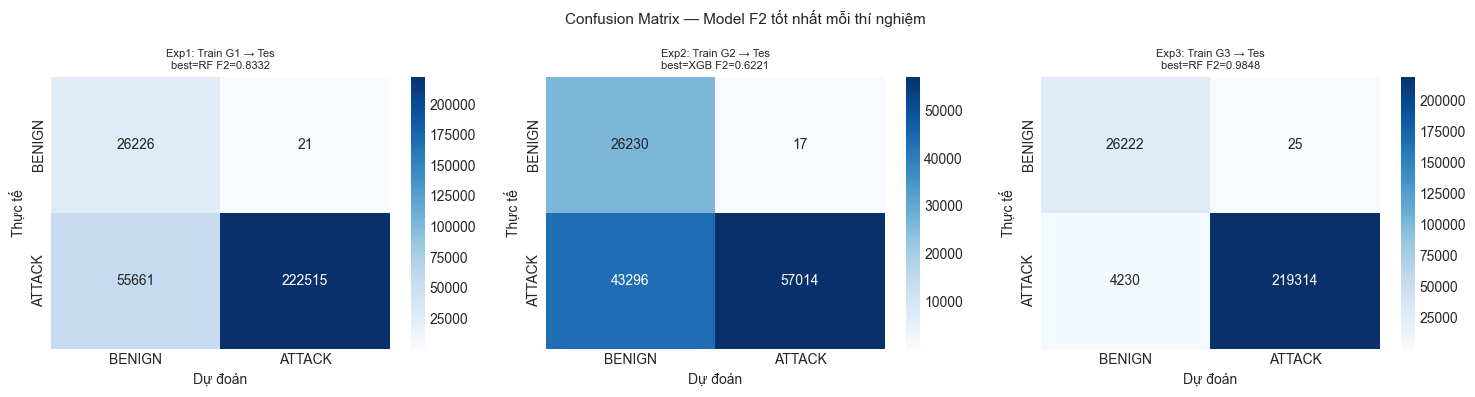

In [10]:
# ── Confusion Matrix (model F2 tốt nhất mỗi thí nghiệm) ─────────────────────
n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4))
if n_exp == 1: axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    best = max(exp['results'], key=lambda m: exp['results'][m]['F2'])
    r  = exp['results'][best]
    cm = confusion_matrix(exp['y_test'], r['_y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['BENIGN','ATTACK'], yticklabels=['BENIGN','ATTACK'])
    ax.set_title(f'{exp_name[:20]}\nbest={best} F2={r["F2"]:.4f}', fontsize=8)
    ax.set_xlabel('Dự đoán'); ax.set_ylabel('Thực tế')

plt.suptitle('Confusion Matrix — Model F2 tốt nhất mỗi thí nghiệm', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.3 Ma trận Nhầm lẫn — Mô hình tốt nhất mỗi thí nghiệm

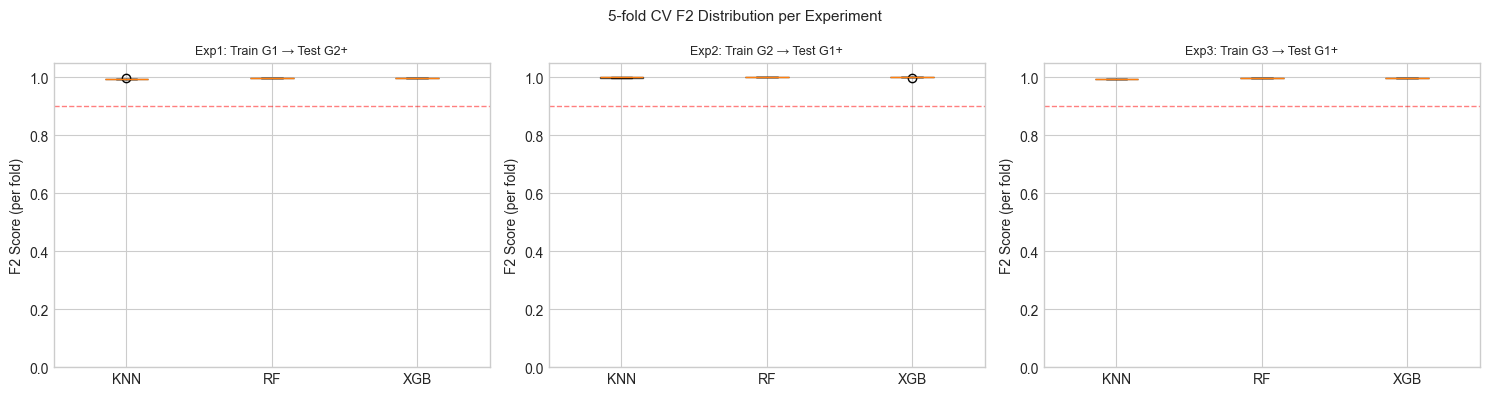

In [11]:
# ── CV Boxplot — phân phối F2 theo fold ──────────────────────────────────────
n_exp = len(all_experiments)
fig, axes = plt.subplots(1, n_exp, figsize=(5*n_exp, 4))
if n_exp == 1: axes = [axes]

for ax, (exp_name, exp) in zip(axes, all_experiments.items()):
    mnames = list(exp['results'].keys())
    cv_data = [exp['results'][m]['_cv_scores'] for m in mnames]
    bp = ax.boxplot(cv_data, labels=mnames, patch_artist=True)
    for patch, clr in zip(bp['boxes'], [COLORS[m] for m in mnames]):
        patch.set_facecolor(clr); patch.set_alpha(0.7)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('F2 Score (per fold)')
    ax.set_title(exp_name[:25], fontsize=9)
    ax.axhline(0.9, color='red', ls='--', lw=1, alpha=0.5)

plt.suptitle('5-fold CV F2 Distribution per Experiment', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_cv_boxplot.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.4 Phân phối CV F2 qua 5 Fold

In [ ]:
# ── Feature Importance — RF và XGB theo từng thí nghiệm ──────────────────────
fig, axes = plt.subplots(len(all_experiments), 2,
                         figsize=(14, 4 * len(all_experiments)))

for row, (exp_name, exp) in enumerate(all_experiments.items()):
    for col, (mname, clr) in enumerate([('RF', 'darkorange'), ('XGB', 'forestgreen')]):
        ax = axes[row][col]
        if mname not in exp['results']:
            ax.axis('off')
            continue
        model = exp['results'][mname]['_model']
        imp = pd.Series(model.feature_importances_, index=feat_cols).sort_values(ascending=True)
        imp.plot(kind='barh', ax=ax, color=clr, alpha=0.85)
        ax.set_title(f'{mname} — {exp_name[:30]}', fontsize=9)
        ax.set_xlabel('Importance', fontsize=8)
        ax.tick_params(axis='y', labelsize=7)

plt.suptitle('Feature Importance theo thí nghiệm (RF & XGB)', fontsize=12, y=1.01)
plt.tight_layout()
fig.savefig('reports/LaTex/hinh/phase2_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### 6.5 Feature Importance — RF và XGB

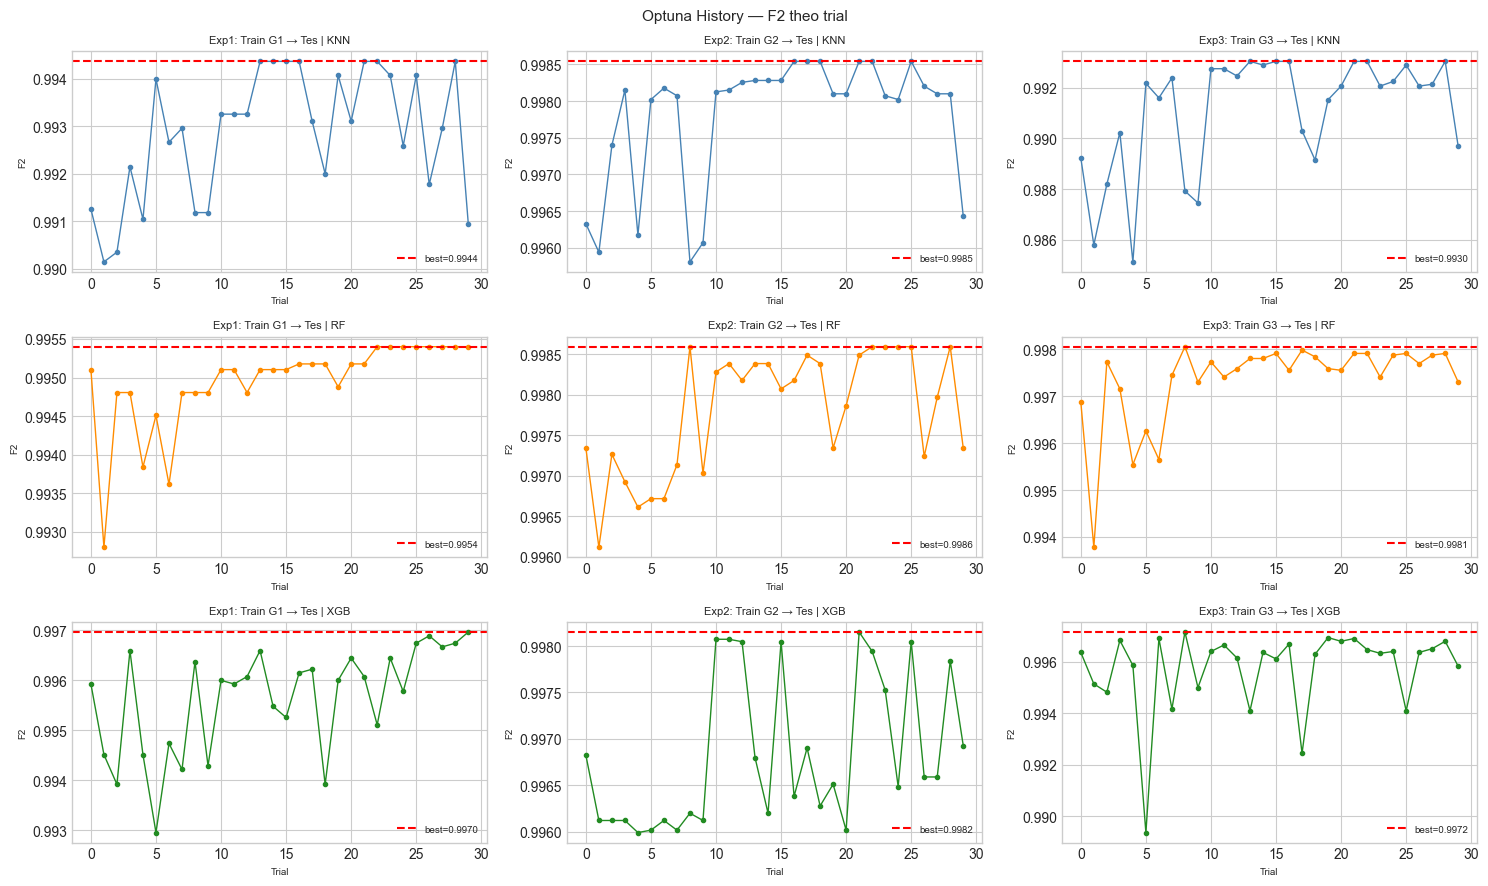

In [13]:
# ── Optuna History ────────────────────────────────────────────────────────────
n_exp = len(all_experiments)
model_names = list(next(iter(all_experiments.values()))['results'].keys())
fig, axes = plt.subplots(len(model_names), n_exp,
                         figsize=(5*n_exp, 3*len(model_names)), squeeze=False)

for col, (exp_name, exp) in enumerate(all_experiments.items()):
    for row, mname in enumerate(model_names):
        ax = axes[row][col]
        if mname not in exp['results']: ax.axis('off'); continue
        study = exp['results'][mname]['_study']
        t_df  = study.trials_dataframe()
        ax.plot(t_df['number'], t_df['value'], 'o-',
                color=list(COLORS.values())[row], ms=3, lw=1)
        ax.axhline(study.best_value, color='red', ls='--', lw=1.5,
                   label=f'best={study.best_value:.4f}')
        ax.set_title(f'{exp_name[:20]} | {mname}', fontsize=8)
        ax.set_xlabel('Trial', fontsize=7); ax.set_ylabel('F2', fontsize=7)
        ax.legend(fontsize=7)

plt.suptitle('Optuna History — F2 theo trial', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_optuna_history.png", dpi=150, bbox_inches='tight')
plt.show()

### 6.6 Lịch sử Hội tụ Optuna

In [14]:
# ── Gap Analysis — CV F2 vs Test F2 ──────────────────────────────────────────
print('PHÂN TÍCH TỔNG QUÁT HOÁ')
print('='*80)
print(f'{"Thí nghiệm":<35} {"Model":<6} {"CV_F2":>14} {"Test_F2":>9} {"FNR":>7} {"Gap":>8}')
print('-'*80)
for exp_name, exp in all_experiments.items():
    for mname, r in exp['results'].items():
        gap  = r['CV_F2_mean'] - r['F2']
        flag = '  ⚠ gap lớn' if abs(gap) > 0.10 else ''
        print(f'{exp_name[:35]:<35} {mname:<6} '
              f'{r["CV_F2_mean"]:.4f}±{r["CV_F2_std"]:.4f}  '
              f'{r["F2"]:.4f}  {r["FNR"]:.4f}  {gap:+.4f}{flag}')
print('='*80)
print('\nGhi chú:')
print('  CV_F2   = 5-fold CV trên tập train (cùng loại tấn công với train)')
print('  Test_F2 = đánh giá trên nhóm tấn công chưa thấy')
print('  FNR     = False Negative Rate = tỷ lệ bỏ sót tấn công')
print('  Gap     = CV_F2 - Test_F2 (dương = overfit vào loại tấn công train)')
print('  ⚠ Gap > 0.10 = cảnh báo tổng quát hoá kém')
print(f'\nFAMS features: {feat_cols}')

PHÂN TÍCH TỔNG QUÁT HOÁ
Thí nghiệm                          Model           CV_F2   Test_F2     FNR      Gap
--------------------------------------------------------------------------------
Exp1: Train G1 → Test G2+G3         KNN    0.9952±0.0008  0.6027  0.4518  +0.3925  ⚠ gap lớn
Exp1: Train G1 → Test G2+G3         RF     0.9972±0.0006  0.8332  0.2001  +0.1640  ⚠ gap lớn
Exp1: Train G1 → Test G2+G3         XGB    0.9976±0.0005  0.7764  0.2647  +0.2212  ⚠ gap lớn
Exp2: Train G2 → Test G1+G3         KNN    0.9991±0.0001  0.6215  0.4321  +0.3776  ⚠ gap lớn
Exp2: Train G2 → Test G1+G3         RF     0.9995±0.0001  0.6196  0.4342  +0.3799  ⚠ gap lớn
Exp2: Train G2 → Test G1+G3         XGB    0.9993±0.0002  0.6221  0.4316  +0.3772  ⚠ gap lớn
Exp3: Train G3 → Test G1+G2 ⚠       KNN    0.9937±0.0007  0.9171  0.1013  +0.0766
Exp3: Train G3 → Test G1+G2 ⚠       RF     0.9981±0.0004  0.9848  0.0189  +0.0133
Exp3: Train G3 → Test G1+G2 ⚠       XGB    0.9978±0.0002  0.9022  0.1193  +0.0956

Ghi c

### 6.7 Phân tích Gap — CV F2 so với Test F2

## 7. Đánh giá Hiệu quả Tính toán

Một trong những lý do áp dụng FAMS là rút gọn số đặc trưng từ 70+ xuống 18, qua đó giảm thời gian huấn luyện và suy luận. Bảng dưới đây so sánh thời gian thực tế của ba mô hình qua ba thí nghiệm.

THỜI GIAN HUẤN LUYỆN & SUY LUẬN (18 đặc trưng FAMS)
                   Thí nghiệm Mô hình Train size  T. huấn luyện (s)  T. suy luận (ms/mẫu)  Test F2
  Exp1: Train G1 → Test G2+G3     KNN     84,082               0.27                0.3148   0.6027
  Exp1: Train G1 → Test G2+G3      RF     84,082               5.85                0.0161   0.8332
  Exp1: Train G1 → Test G2+G3     XGB     84,082               1.97                0.0034   0.7764
  Exp2: Train G2 → Test G1+G3     KNN    261,948               1.51                0.1760   0.6215
  Exp2: Train G2 → Test G1+G3      RF    261,948               1.18                0.0027   0.6196
  Exp2: Train G2 → Test G1+G3     XGB    261,948              13.11                0.0082   0.6221
Exp3: Train G3 → Test G1+G2 ⚠     KNN    138,714               0.08                0.6512   0.9171
Exp3: Train G3 → Test G1+G2 ⚠      RF    138,714               4.94                0.0106   0.9848
Exp3: Train G3 → Test G1+G2 ⚠     XGB    138,714         

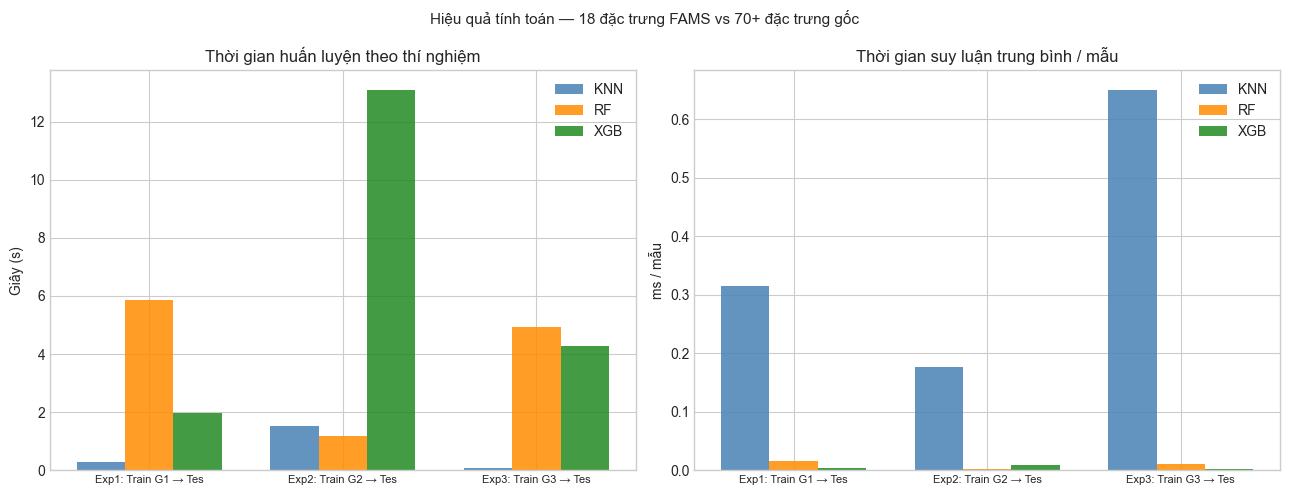


Đã lưu: reports/LaTex/hinh/phase2_timing.png


In [15]:
# ── Bảng tổng hợp thời gian huấn luyện và suy luận ──────────────────────────
timing_rows = []
for exp_name, exp in all_experiments.items():
    for mname, r in exp['results'].items():
        timing_rows.append({
            'Thí nghiệm': exp_name[:30],
            'Mô hình':    mname,
            'Train size': f"{len(pd.concat([ben_train, attack_df[attack_df['Group']==exp['train_group']]])):,}",
            'T. huấn luyện (s)':       r['Train_Time_s'],
            'T. suy luận (ms/mẫu)':    r['Infer_ms_per_sample'],
            'Test F2':    r['F2'],
        })

timing_df = pd.DataFrame(timing_rows)
print('=' * 85)
print('THỜI GIAN HUẤN LUYỆN & SUY LUẬN (18 đặc trưng FAMS)')
print('=' * 85)
print(timing_df.to_string(index=False))

# Tóm tắt trung bình theo mô hình
print('\n─── Trung bình theo mô hình (qua 3 thí nghiệm) ───')
avg = timing_df.groupby('Mô hình')[['T. huấn luyện (s)', 'T. suy luận (ms/mẫu)']].mean().round(4)
print(avg.to_string())

# ── Biểu đồ so sánh ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Plot 1: Thời gian huấn luyện
exp_labels = [r['Thí nghiệm'][:20] for r in timing_rows if r['Mô hình'] == 'KNN']
x = np.arange(len(exp_labels))
width = 0.25
for i, mname in enumerate(['KNN', 'RF', 'XGB']):
    vals = [r['T. huấn luyện (s)'] for r in timing_rows if r['Mô hình'] == mname]
    axes[0].bar(x + i*width, vals, width, label=mname, color=list(COLORS.values())[i], alpha=0.85)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(exp_labels, fontsize=8)
axes[0].set_ylabel('Giây (s)')
axes[0].set_title('Thời gian huấn luyện theo thí nghiệm')
axes[0].legend()

# Plot 2: Thời gian suy luận
for i, mname in enumerate(['KNN', 'RF', 'XGB']):
    vals = [r['T. suy luận (ms/mẫu)'] for r in timing_rows if r['Mô hình'] == mname]
    axes[1].bar(x + i*width, vals, width, label=mname, color=list(COLORS.values())[i], alpha=0.85)
axes[1].set_xticks(x + width)
axes[1].set_xticklabels(exp_labels, fontsize=8)
axes[1].set_ylabel('ms / mẫu')
axes[1].set_title('Thời gian suy luận trung bình / mẫu')
axes[1].legend()

plt.suptitle('Hiệu quả tính toán — 18 đặc trưng FAMS vs 70+ đặc trưng gốc', fontsize=11)
plt.tight_layout()
fig.savefig("reports/LaTex/hinh/phase2_timing.png", dpi=150, bbox_inches='tight')
plt.show()
print(f'\nĐã lưu: reports/LaTex/hinh/phase2_timing.png')

## 8. Phân tích Giới hạn

### Exp 1 & 2 — Gap lớn (0,16–0,39)

- **G1** chỉ có 22.839 mẫu tấn công — tập huấn luyện nhỏ, thiên về đặc trưng giao thức phản xạ ứng dụng (DNS, LDAP, MSSQL), không đại diện cho pattern DDoS tổng quát.
- **G2** (NTP, TFTP) tạo lưu lượng rất đồng đều về kích thước gói tin và cổng UDP đặc thù, khiến mô hình học biên quyết định hẹp theo giao thức thay vì học đặc trưng tấn công chung. Lưu ý rằng với G2, RF không còn lợi thế so với KNN và XGB (ba mô hình hội tụ về cùng Gap ≈ 0,38), vì bootstrap sampling của RF cũng bị giới hạn bởi sự đồng nhất của dữ liệu nguồn.
- 18 đặc trưng FAMS được chọn từ bộ dữ liệu Kaggle (chứa nhiều tấn công thể tích như UDP Flood, Syn Flood) — tạo ra độ lệch nhất định về phía G3 so với G1/G2.

### Exp 3 — Kết quả xuất sắc (RF Test F2 = 0,9848, Gap = 0,013)

- **G3** (Syn, UDP, UDPLag, WebDDoS) bao gồm cả tấn công thể tích và tầng ứng dụng, tạo ra đặc trưng huấn luyện đa dạng và tương thích tốt với 18 đặc trưng FAMS.
- Cơ chế bagging của RF hoạt động hiệu quả khi dữ liệu bootstrap đa dạng — mỗi cây học một phần khác nhau của pattern tấn công, giảm phương sai và tăng khả năng tổng quát hóa.

### Giới hạn chung của nghiên cứu

- Dữ liệu từ môi trường lab (CIC-DDoS 2019) — không phản ánh đầy đủ sự đa dạng traffic trong mạng thực tế.
- Mô hình tĩnh — không thích nghi với concept drift khi phân phối traffic thay đổi theo thời gian.
- WebDDoS chỉ có 51 mẫu — kết quả Exp 3 có thể thiên về nhóm tấn công có nhiều mẫu hơn (Syn, UDP).
- Đánh giá dừng ở mức binary classification (DDoS / Benign), chưa phân loại đa lớp theo loại tấn công cụ thể.